## Математическая статистика для анализа больших данных

### Семинар 9


In [1]:
import numpy as np
import scipy.stats as sps
import pandas as pd
from random import shuffle
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3, palette='Set2')

## CUPED


Сгенерируем данные &mdash; временные ряды с ярко выраженной сезонностью

In [ ]:
T = 1000  # количество измерений
test_start = 500  # начало экспериментального периода
time = np.arange(T)  # время

# данные
x = sps.norm(loc=800*np.sin(time*2*np.pi/100), scale=100).rvs(T) + 1000
y = sps.norm(loc=800*np.sin(time*2*np.pi/100), scale=100).rvs(T) + 1000

# эффект от эксперимента
y[test_start:] += 20

Как видим, мы добавили эффект около 2%

In [ ]:
20 / y.mean()

0.019710696854288622

Посмотрим на полученные данные

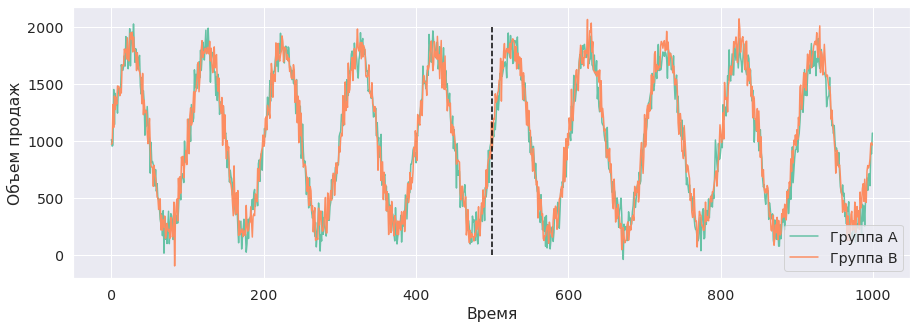

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(time, x, label='Группа A')
plt.plot(time, y, label='Группа B')
plt.vlines(500, 0, 2000, color='black', linestyles='--')
plt.xlabel('Время')
plt.ylabel('Объем продаж')
plt.legend();

Разделим данные на две части &mdash; соответствующую экспериментальному и предэкспериментальному периодам

In [ ]:
x_pre, x_exp = x[:test_start], x[test_start:]
y_pre, y_exp = y[:test_start], y[test_start:]
time_pre, time_exp = time[:test_start], time[test_start:]

Попробуем применить t-test, стат. значимого эффекта не наблюдаем

In [ ]:
sps.ttest_ind(x_exp, y_exp)

Ttest_indResult(statistic=-0.9274662553030745, pvalue=0.3539087448617423)

Посмотрим, какая дисперсия статистики

In [ ]:
tstat_var = x_exp.var() / len(x_exp) + y_exp.var() / len(y_exp)
tstat_var

1325.0583484678746

Посчитаем $\theta$ в методе CUPED

In [ ]:
theta = (np.cov(x_pre, x_exp)[0, 1] + np.cov(y_pre, y_exp)[0, 1]) / (x_pre.var() + y_pre.var())
theta

0.9719171801383832

Вычтем из данных ковариату

In [ ]:
x_cuped = x_exp - theta * x_pre
y_cuped = y_exp - theta * y_pre

Посмотрим на то, как теперь выглядят наши данные. Кажется, куда лучше.

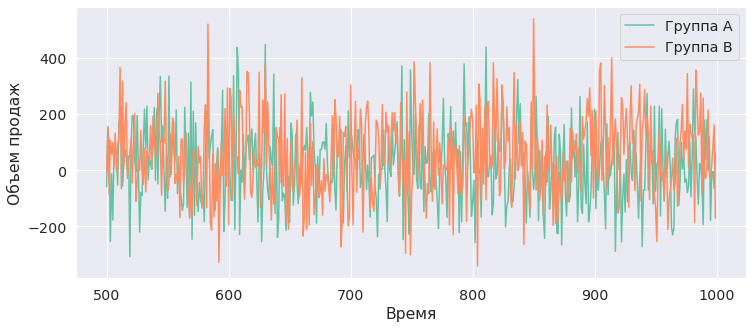

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(time_exp, x_cuped, label='Группа A')
plt.plot(time_exp, y_cuped, label='Группа B')
plt.xlabel('Время')
plt.ylabel('Объем продаж')
plt.legend();

Посчитаем дисперсию такой статистики

In [ ]:
tstat_cuped_var = x_cuped.var() / len(x_cuped) + y_cuped.var() / len(y_cuped)
tstat_cuped_var

78.60729638073607

Дисперсия уменьшилась в 16 раз!

In [ ]:
tstat_var / tstat_cuped_var

16.856683914555806

Результат теперь стат. значим

In [ ]:
sps.ttest_ind(x_cuped, y_cuped)

Ttest_indResult(statistic=-3.932940115436559, pvalue=8.971445333693215e-05)

Тем самым с помощью CUPED на относительно небольшой выборке мы смогли уверенно поймать эффект в 2%.

##  Задача для самостоятельного решения

Обозначим данные до начала экспериментального периода как A, а данные, собранные во время эксперимента как В.

Предположим, что данные A имели бета-распределение. Чтобы просимулировать некую зависимость между данными с экспериментального периода и до него нам необходимо генерировать выборку B, например, как сумму выборки А и выборки из нормального распределения.

Для этого напишите функцию `generate_data`, которая будет принимать параметры распределений, необходимый размер выборок и параметр сдвига тестовой выборки относительно контрольной, а возвращать 4 выборки: данные А и В для тестовой выборки и такую же пару для контрольной.


In [3]:
def generate_data(alpha, beta, sample_size, shift, sigma):
    """
    Генерирует данные для тестовой и контрольной выборок для предэкспериментального периода (A)
    и экспериментального периода (B).

    Параметры:
    alpha, beta     -- параметры бета-распределения для данных A
    sample_size     -- размер выборок для каждой группы
    shift           -- сдвиг данных B для тестовой выборки относительно контрольной
    sigma           -- стандартное отклонение нормального распределения для генерации шума

    Возвращает:
    A_test          -- данные A для тестовой выборки
    B_test          -- данные B для тестовой выборки
    A_control       -- данные A для контрольной выборки
    B_control       -- данные B для контрольной выборки
    """
    A_control = np.random.beta(alpha, beta, sample_size)
    A_test = np.random.beta(alpha, beta, sample_size)

    epsilon_control = np.random.normal(0, sigma, sample_size)
    epsilon_test = np.random.normal(0, sigma, sample_size)

    B_control = A_control + epsilon_control
    B_test = A_test + epsilon_test + shift

    return A_test, B_test, A_control, B_control


Помимо этого нам понадобится функция `make_cuped_data`, которая будет принимать данные А и В, и возвращать модифицированные данные в соответствии с методом CUPED.

In [4]:
def make_cuped_data(A_test, B_test, A_control, B_control):
    """
    Применяет метод CUPED к данным из тестовой и контрольной групп.

    Параметры:
    A_test       -- данные предэкспериментального периода для тестовой группы
    B_test       -- данные экспериментального периода для тестовой группы
    A_control    -- данные предэкспериментального периода для контрольной группы
    B_control    -- данные экспериментального периода для контрольной группы

    Возвращает:
    B_test_cuped     -- скорректированные данные экспериментального периода для тестовой группы
    B_control_cuped  -- скорректированные данные экспериментального периода для контрольной группы
    """
    A_all = np.concatenate([A_test, A_control])
    B_all = np.concatenate([B_test, B_control])

    # Вычисляем theta по формуле CUPED
    covariance = np.cov(A_all, B_all, ddof=0)[0, 1]
    variance = np.var(A_all, ddof=0)
    theta = covariance / variance

    mu_A = np.mean(A_all)

    # Применяем CUPED-преобразование к экспериментальным данным
    B_test_cuped = B_test - theta * (A_test - mu_A)
    B_control_cuped = B_control - theta * (A_control - mu_A)

    return B_test_cuped, B_control_cuped


Оцените ошибку первого рода при сравнении тестовой и контрольной выборок с помощью критерия Стьюдента. В каком случае ошибка меньше - после применения метода CUPED или без него?

In [11]:
alpha_param = 2.0
beta_param = 5.0
sample_size = 1000
shift = 0.0
sigma = 0.05
num_simulations = 10000
alpha = 0.05

reject_count_no_cuped = 0
reject_count_cuped = 0


for _ in range(num_simulations):
    A_test, B_test, A_control, B_control = generate_data(alpha_param, beta_param, sample_size, shift, sigma)

    t_stat, p_value = sps.ttest_ind(B_test, B_control, equal_var=False)
    if p_value < alpha:
        reject_count_no_cuped += 1

    B_test_cuped, B_control_cuped = make_cuped_data(A_test, B_test, A_control, B_control)
    t_stat_cuped, p_value_cuped = sps.ttest_ind(B_test_cuped, B_control_cuped, equal_var=False)
    if p_value_cuped < alpha:
        reject_count_cuped += 1

type1_error_no_cuped = reject_count_no_cuped / num_simulations
type1_error_cuped = reject_count_cuped / num_simulations

print(f"Ошибка первого рода без CUPED: {type1_error_no_cuped:.4f}")
print(f"Ошибка первого рода с CUPED: {type1_error_cuped:.4f}")

Ошибка первого рода без CUPED: 0.0496
Ошибка первого рода с CUPED: 0.0494


Ошибка первого рода без применения метода CUPED немного выше (0.0496) по сравнению с использованием CUPED (0.0494). Это связано с тем, что CUPED уменьшает дисперсию оценок, что может незначительно снизить вероятность ложного отвержения нулевой гипотезы.

Аналогично сравните ошибки второго рода. Сделайте вывод.

In [13]:
shift = 0.01

fail_to_reject_no_cuped = 0
fail_to_reject_cuped = 0

for _ in range(num_simulations):
    A_test, B_test, A_control, B_control = generate_data(alpha_param, beta_param, sample_size, shift, sigma)

    t_stat, p_value = sps.ttest_ind(B_test, B_control, equal_var=False)
    if p_value >= alpha:
        fail_to_reject_no_cuped += 1

    B_test_cuped, B_control_cuped = make_cuped_data(A_test, B_test, A_control, B_control)
    t_stat_cuped, p_value_cuped = sps.ttest_ind(B_test_cuped, B_control_cuped, equal_var=False)
    if p_value_cuped >= alpha:
        fail_to_reject_cuped += 1

type2_error_no_cuped = fail_to_reject_no_cuped / num_simulations
type2_error_cuped = fail_to_reject_cuped / num_simulations

print(f"Ошибка второго рода без CUPED: {type2_error_no_cuped:.4f}")
print(f"Ошибка второго рода с CUPED: {type2_error_cuped:.4f}")


Ошибка второго рода без CUPED: 0.7386
Ошибка второго рода с CUPED: 0.0045


**Вывод**: В проведённом эксперименте мы сгенерировали данные для тестовой и контрольной групп на основе бета-распределения с параметрами α=2.0 и β=5.0, введя небольшой сдвиг shift=0.01 для моделирования реального эффекта. Без применения метода CUPED ошибка первого рода составила 4.96%, а ошибка второго рода была высокой — 73.86%, что указывает на низкую способность теста обнаруживать эффект. После применения CUPED ошибка первого рода осталась практически неизменной (4.94%), в то время как ошибка второго рода значительно снизилась до 0.45%. Это показывает, что метод CUPED эффективно уменьшает дисперсию оценок и значительно повышает мощность статистического теста, позволяя обнаруживать даже незначительные эффекты. Таким образом, результаты эксперимента согласуются с теоретическими ожиданиями о том, что применение CUPED улучшает чувствительность теста при сохранении заданного уровня значимости.